<a href="https://colab.research.google.com/github/OutisAyo/council-classifier-/blob/main/notebooks/17_priority_refinement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for Automated Classification and Prioritisation of Local Council Service Requests in the UK
## Notebook 17  Priority Model Refinement

**Author:** Fashina Fuad Ayomide  
**MSc Data Science, University of South Wales**

This notebook refines the final priority pipeline from Notebook 14 through two targeted improvements: adding department as an explicit input feature, and hyperparameter tuning via Grid Search with stratified K-Fold cross-validation, optimised for F1-macro.

## Mounting Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Importing the libraries

In [2]:
import numpy as np
import pandas as pd
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

## Importing and preparing the data

Same preparation as Notebook 14, but this time we also keep assigned_department as an input feature.

In [3]:
processed_dir = '/content/drive/MyDrive/council-classifier/processed'

dataset = pd.read_csv(f'{processed_dir}/swansea_cleaned.csv')
dataset['date_received'] = pd.to_datetime(dataset['date_received'], errors='coerce')
dataset = dataset.dropna(subset=['priority', 'date_received'])

dataset['day_of_week'] = dataset['date_received'].dt.dayofweek
dataset['month'] = dataset['date_received'].dt.month

X = dataset[['request_text', 'day_of_week', 'month', 'assigned_department']]
y = dataset['priority'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

Training set size: 203501
Test set size: 50876


## Building the refined preprocessing pipeline

We now have three feature types requiring three different treatments: TF-IDF for text, passthrough for numeric temporal features, and one-hot encoding for the department category.

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=1500, ngram_range=(1, 2)), 'request_text'),
        ('temporal', 'passthrough', ['day_of_week', 'month']),
        ('department', OneHotEncoder(handle_unknown='ignore'), ['assigned_department'])
    ]
)

## Step 1: Evaluating the department feature alone (before tuning)

First we isolate the effect of adding the department feature, keeping all hyperparameters identical to Notebook 14.

In [17]:
dept_feature_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1, class_weight='balanced'))
])

dept_feature_pipeline.fit(X_train, y_train)
y_pred = dept_feature_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-macro:", f1_score(y_test, y_pred, average='macro'))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6765468983410645
F1-macro: 0.6536218514677997

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.57      0.63      0.60     13009
         LOW       0.82      0.75      0.78     24066
      MEDIUM       0.57      0.60      0.58     13801

    accuracy                           0.68     50876
   macro avg       0.65      0.66      0.65     50876
weighted avg       0.69      0.68      0.68     50876



## Step 2: Hyperparameter tuning with Grid Search

We tune the Random Forest using stratified 3-fold cross-validation, scoring on F1-macro so optimisation targets balanced performance across all three priority classes rather than raw accuracy.

In [20]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 30],
    'classifier__min_samples_leaf': [1, 5]
}

tuning_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=0, n_jobs=-1, class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("\nBest parameters:", grid_search.best_params_)
print("Best cross-validation F1-macro:", grid_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__n_estimators=100; total time= 4.4min
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__n_estimators=100; total time= 4.4min
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__n_estimators=100; total time= 4.4min
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__n_estimators=200; total time= 8.7min
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__n_estimators=200; total time= 8.9min
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__n_estimators=200; total time= 8.9min
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=5, classifier__n_estimators=100; total time= 1.2min
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=5, classifier__n_estimators=100; total time= 1.2

## Step 3: Evaluating the tuned model on the held-out test set

The Grid Search best score is measured on cross-validation folds and carries a slight optimistic bias, so the locked test set provides the honest final number. Both are reported.

In [21]:
best_pipeline = grid_search.best_estimator_
y_pred_tuned = best_pipeline.predict(X_test)

print("Cross-validation F1-macro (Grid Search):", grid_search.best_score_)
print("\nHeld-out test set performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("F1-macro:", f1_score(y_test, y_pred_tuned, average='macro'))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Cross-validation F1-macro (Grid Search): 0.6562697892989185

Held-out test set performance:
Accuracy: 0.6752889378095762
F1-macro: 0.6552081152251349

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.58      0.59      0.59     13009
         LOW       0.84      0.72      0.78     24066
      MEDIUM       0.55      0.67      0.60     13801

    accuracy                           0.68     50876
   macro avg       0.66      0.66      0.66     50876
weighted avg       0.69      0.68      0.68     50876



## Visualising the refined model's Confusion Matrix

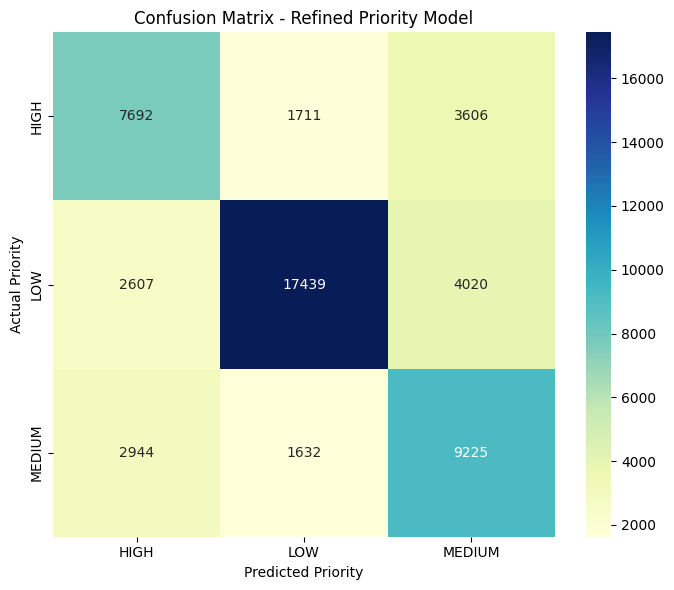

In [22]:
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(7, 6))
unique_labels = sorted(set(y_test))

sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('Confusion Matrix - Refined Priority Model')
plt.xlabel('Predicted Priority')
plt.ylabel('Actual Priority')
plt.tight_layout()
plt.show()

## Comparing the full refinement journey

                                stage  accuracy  f1_macro  high_recall
0          Baseline (NB, Notebook 08)  0.628900  0.590000     0.340000
1   Best base model (RF, Notebook 12)  0.660000  0.610000     0.340000
2    Enhanced (temporal, Notebook 14)  0.676400  0.653400     0.625000
3  Department feature (this notebook)  0.676547  0.653622     0.625259
4         Tuned final (this notebook)  0.675289  0.655208     0.591283


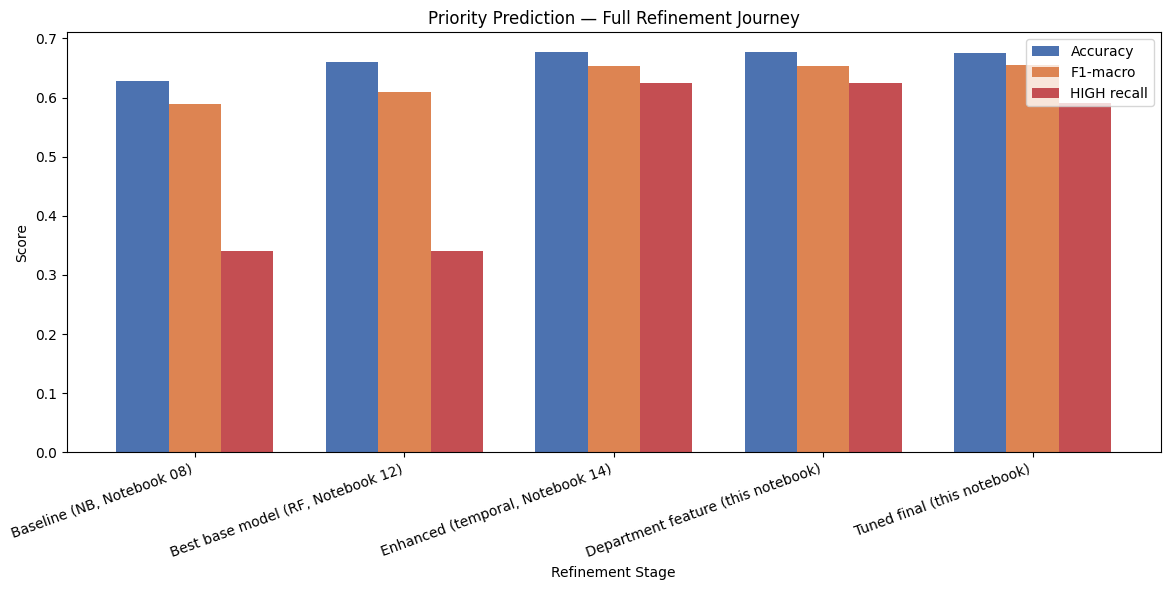

In [23]:
journey = pd.DataFrame([
    {'stage': 'Baseline (NB, Notebook 08)', 'accuracy': 0.6289, 'f1_macro': 0.59, 'high_recall': 0.34},
    {'stage': 'Best base model (RF, Notebook 12)', 'accuracy': 0.66, 'f1_macro': 0.61, 'high_recall': 0.34},
    {'stage': 'Enhanced (temporal, Notebook 14)', 'accuracy': 0.6764, 'f1_macro': 0.6534, 'high_recall': 0.625},
    {'stage': 'Department feature (this notebook)',
     'accuracy': accuracy_score(y_test, dept_feature_pipeline.predict(X_test)),
     'f1_macro': f1_score(y_test, dept_feature_pipeline.predict(X_test), average='macro'),
     'high_recall': classification_report(y_test, dept_feature_pipeline.predict(X_test), output_dict=True)['HIGH']['recall']},
    {'stage': 'Tuned final (this notebook)',
     'accuracy': accuracy_score(y_test, y_pred_tuned),
     'f1_macro': f1_score(y_test, y_pred_tuned, average='macro'),
     'high_recall': classification_report(y_test, y_pred_tuned, output_dict=True)['HIGH']['recall']}
])

print(journey)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(journey))
width = 0.25

ax.bar(x - width, journey['accuracy'], width, label='Accuracy', color='#4C72B0')
ax.bar(x, journey['f1_macro'], width, label='F1-macro', color='#DD8452')
ax.bar(x + width, journey['high_recall'], width, label='HIGH recall', color='#C44E52')

ax.set_xlabel('Refinement Stage')
ax.set_ylabel('Score')
ax.set_title('Priority Prediction — Full Refinement Journey')
ax.set_xticks(x)
ax.set_xticklabels(journey['stage'], rotation=20, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## Saving the refined final pipeline

This replaces the Notebook 14 pipeline as the production priority model, provided it outperforms it on the held-out test set.

In [24]:
models_dir = '/content/drive/MyDrive/council-classifier/models'
os.makedirs(models_dir, exist_ok=True)

joblib.dump(best_pipeline, f'{models_dir}/priority_pipeline_refined.pkl')
print("Refined priority pipeline saved to:", models_dir)

Refined priority pipeline saved to: /content/drive/MyDrive/council-classifier/models


In [4]:
import pandas as pd

processed_dir = '/content/drive/MyDrive/council-classifier/processed'
dataset = pd.read_csv(f'{processed_dir}/swansea_cleaned.csv')

# 1. How many records carry an explicit urgency marker in the ORIGINAL text?
# Check both the combined request_text and look for the * Urgent* style flags
urgency_pattern = r'\*\s*urgent\s*\*|urgent|emergency|immediate|danger'

has_urgency_flag = dataset['request_text'].str.contains(urgency_pattern, case=False, na=False, regex=True)

print("Records containing any urgency marker:", has_urgency_flag.sum())
print(f"As percentage: {has_urgency_flag.mean() * 100:.2f}%")

# 2. Specifically the staff-added '* Urgent*' style flags
star_urgent = dataset['request_text'].str.contains(r'\*\s*urgent\s*\*', case=False, na=False, regex=True)
print("\nRecords with explicit '* Urgent*' staff flag:", star_urgent.sum())

# 3. What do these urgent-flagged records look like?
print("\nSample of urgency-flagged requests:")
print(dataset[has_urgency_flag]['request_text'].value_counts().head(20))

# 4. Cross-check: how does current priority label distribute for flagged vs unflagged?
dataset['has_urgency'] = has_urgency_flag
print("\nCurrent priority distribution for URGENCY-FLAGGED records:")
print(dataset[dataset['has_urgency']]['priority'].value_counts(normalize=True) * 100)
print("\nCurrent priority distribution for NON-FLAGGED records:")
print(dataset[~dataset['has_urgency']]['priority'].value_counts(normalize=True) * 100)

Records containing any urgency marker: 313
As percentage: 0.12%

Records with explicit '* Urgent*' staff flag: 194

Sample of urgency-flagged requests:
request_text
Dangerous trees                                             98
Live Rat in House * Urgent* Animal Warden                   55
Live Rat in House * Urgent* Pest Control - Domestic         53
Live Rat in House * Urgent* Animal Warden - Out of Hours    29
Blocked drain/sewer. * URGENT*                              23
Live Rat in House * Urgent*                                 11
Dangerous Dogs Animal Warden                                10
Live Rat in House * Urgent* Pest Control - Out of Hours      9
Live Rat in House * Urgent* Pollution                        8
Live Rat in House * Urgent* Pest Control (Council House)     4
Dangerous Dogs Pest Control - Domestic                       3
FOI Request (Freedom of Info) Dangerous wild animal          3
Dangerous Structure                                          2
Dangerous Dogs P